# Publication-oriented descriptive figures

This notebook generates transparent, publication-ready descriptive figures for the observed ST-OSA-PS-OMT therapy cohort. It supports comparison with other cohorts, but does not establish external population representativeness without an independently defined reference population, sampling design, or weights.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})
DATA = Path("../data/processed/en/data.csv")
CODEBOOK = Path("../data/processed/en/data.dictionary.json")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
df = pd.read_csv(DATA, na_values=["NA"])
with CODEBOOK.open(encoding="utf-8") as handle:
    dictionary = json.load(handle)
mappings = dictionary["value_mappings"]

def decode(column):
    return df[column].map({int(code): label for code, label in mappings[column].items() if code != "NA"})

df["sex_label"] = decode("sex")
df["treatment_label"] = decode("treatment_level_1")
df.shape

(126, 40)

## Cohort profile


In [2]:
profile = pd.DataFrame({
    "measure": ["Total participants", "Male", "Female", "Age (years)", "BMI", "Baseline Epworth", "Baseline AHI"],
    "value": [len(df), (df["sex"] == 0).sum(), (df["sex"] == 1).sum(), f"{df['age'].mean():.1f} ± {df['age'].std():.1f}", f"{df['bmi'].mean():.1f} ± {df['bmi'].std():.1f}", f"{df['baseline_epworth'].mean():.1f} ± {df['baseline_epworth'].std():.1f}", f"{df['baseline_ahi'].mean():.1f} ± {df['baseline_ahi'].std():.1f}"]
})
profile

,measure,value
0,Total participants,126
1,Male,44
2,Female,82
3,Age (years),48.7 ± 12.8
4,BMI,27.1 ± 4.4
5,Baseline Epworth,9.4 ± 5.7
6,Baseline AHI,11.2 ± 7.8


## Figure 1: cohort composition


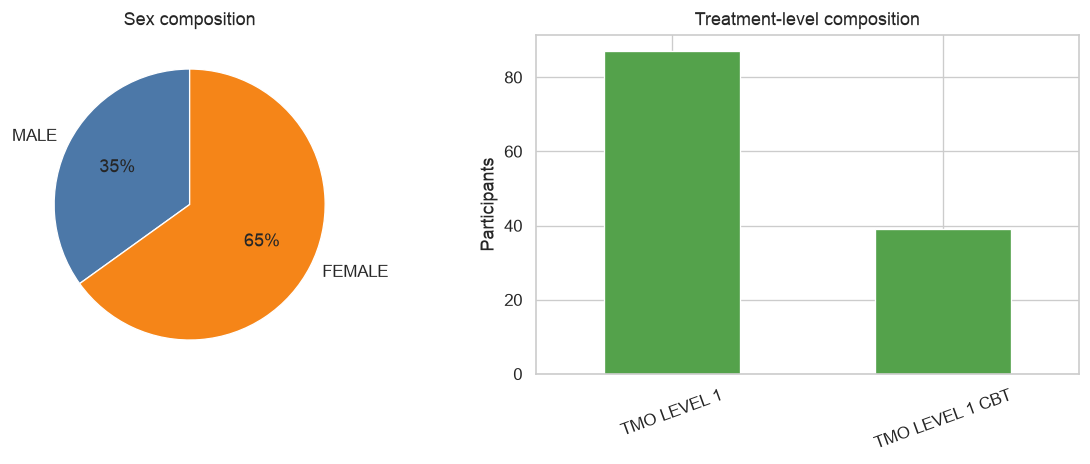

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["sex_label"].value_counts().reindex(["MALE", "FEMALE"]).plot.pie(ax=axes[0], autopct="%1.0f%%", startangle=90, ylabel="", colors=["#4c78a8", "#f58518"])
axes[0].set_title("Sex composition")
df["treatment_label"].value_counts().sort_index().plot.bar(ax=axes[1], color="#54a24b")
axes[1].set(title="Treatment-level composition", xlabel="", ylabel="Participants")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURES / "figure_1_cohort_composition.png", bbox_inches="tight")
plt.show()

## Figure 2: age and BMI by sex


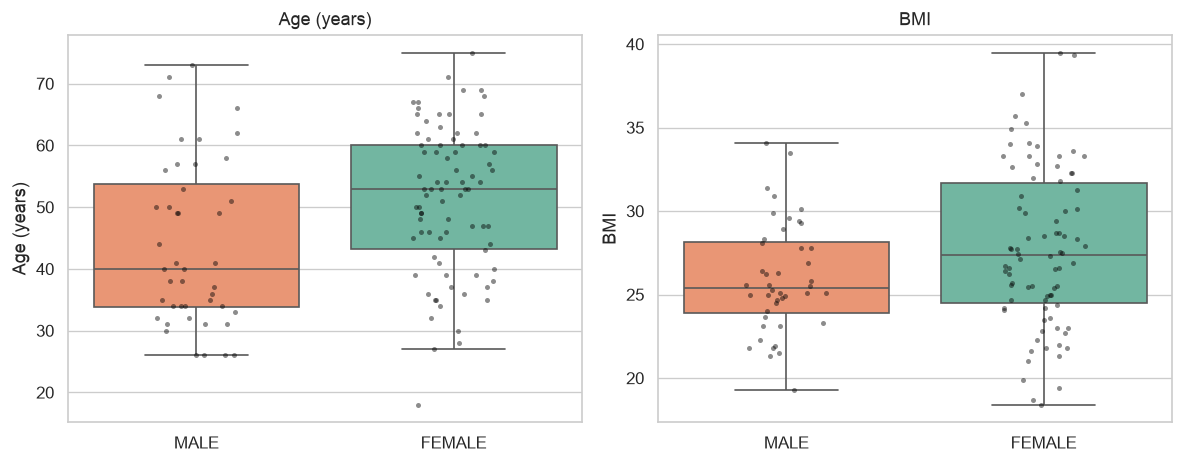

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, column, label in zip(axes, ["age", "bmi"], ["Age (years)", "BMI"]):
    values = df[["sex_label", column]].dropna()
    sns.boxplot(data=values, x="sex_label", y=column, order=["MALE", "FEMALE"], hue="sex_label", legend=False, palette="Set2", showfliers=False, ax=ax)
    sns.stripplot(data=values, x="sex_label", y=column, order=["MALE", "FEMALE"], color="black", alpha=0.45, jitter=0.16, size=3, ax=ax)
    ax.set(title=label, xlabel="", ylabel=label)
fig.tight_layout()
fig.savefig(FIGURES / "figure_2_age_bmi_by_sex.png", bbox_inches="tight")
plt.show()

## Figure 3: sleep and oxygenation distributions


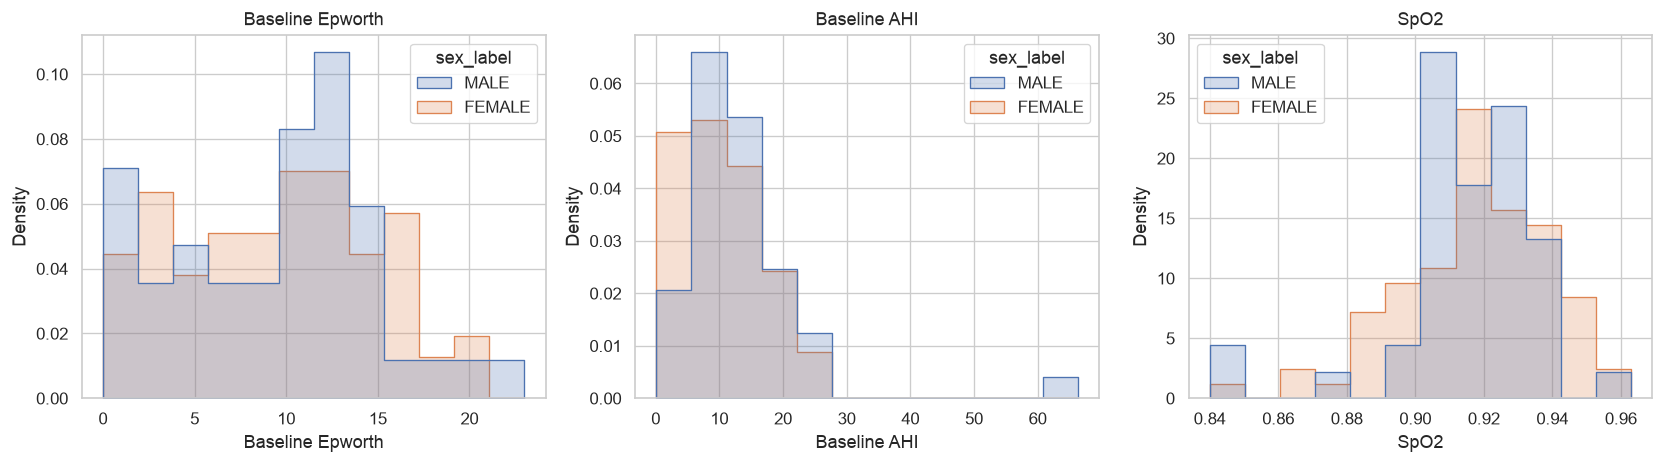

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, column, label in zip(axes, ["baseline_epworth", "baseline_ahi", "spo2"], ["Baseline Epworth", "Baseline AHI", "SpO2"]):
    sns.histplot(data=df, x=column, hue="sex_label", hue_order=["MALE", "FEMALE"], element="step", stat="density", common_norm=False, bins=12, ax=ax)
    ax.set(title=label, xlabel=label, ylabel="Density")
fig.tight_layout()
fig.savefig(FIGURES / "figure_3_sleep_oxygenation_distributions.png", bbox_inches="tight")
plt.show()

## Figure 4: comorbidity prevalence with 95% Wilson intervals


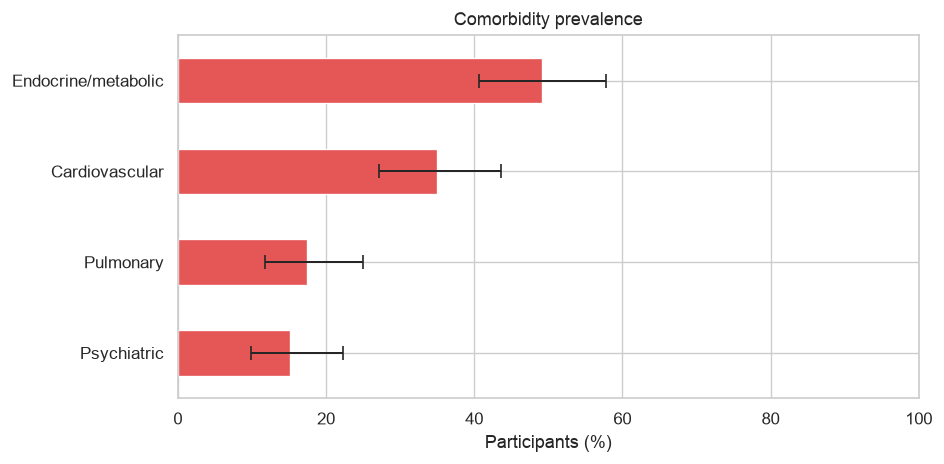

,condition,percent,lower,upper
2,Psychiatric,15.1,9.9,22.4
3,Pulmonary,17.5,11.8,25.0
0,Cardiovascular,34.9,27.2,43.6
1,Endocrine/metabolic,49.2,40.6,57.8


In [6]:
comorbidity_columns = {"cardiovascular_comorbidity": "Cardiovascular", "endocrine_metabolic_comorbidity": "Endocrine/metabolic", "psychiatric_comorbidity": "Psychiatric", "pulmonary_comorbidity": "Pulmonary"}
def wilson_interval(successes, total, z=1.96):
    p = successes / total
    denominator = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denominator
    return center - margin, center + margin
prevalence = []
for column, label in comorbidity_columns.items():
    total = df[column].notna().sum()
    successes = (df[column] == 1).sum()
    lower, upper = wilson_interval(successes, total)
    prevalence.append({"condition": label, "percent": 100 * successes / total, "lower": 100 * lower, "upper": 100 * upper})
prevalence = pd.DataFrame(prevalence).sort_values("percent")
ax = prevalence.plot.barh(x="condition", y="percent", legend=False, color="#e45756", figsize=(8, 4), xerr=[prevalence["percent"] - prevalence["lower"], prevalence["upper"] - prevalence["percent"]], capsize=4)
ax.set(title="Comorbidity prevalence", xlabel="Participants (%)", ylabel="")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(FIGURES / "figure_4_comorbidity_prevalence.png", bbox_inches="tight")
plt.show()
prevalence.round(1)

## Figure 5: Spearman correlation structure


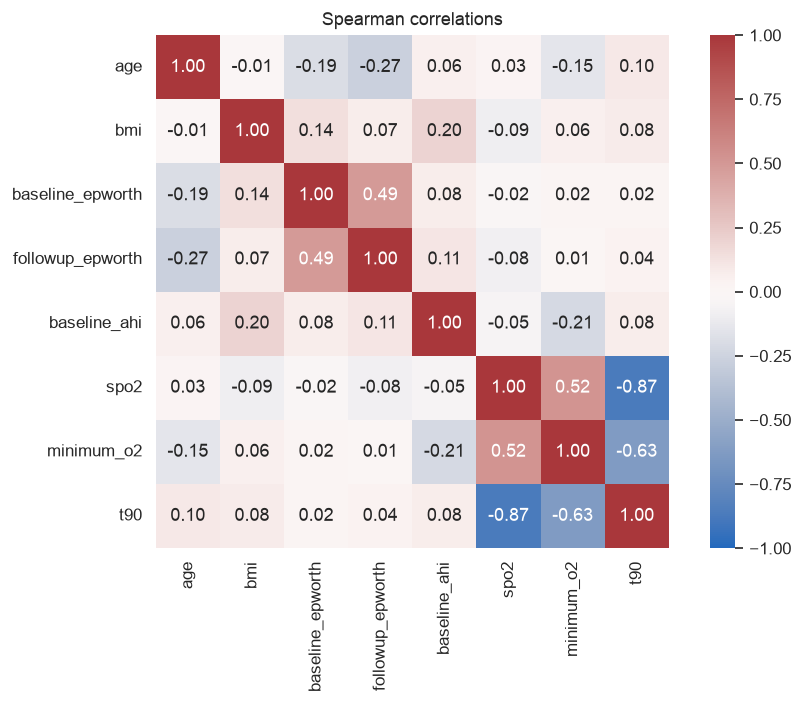

In [7]:
continuous = ["age", "bmi", "baseline_epworth", "followup_epworth", "baseline_ahi", "spo2", "minimum_o2", "t90"]
correlation = df[continuous].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, annot=True, fmt=".2f", ax=ax)
ax.set_title("Spearman correlations")
fig.tight_layout()
fig.savefig(FIGURES / "figure_5_correlation_matrix.png", bbox_inches="tight")
plt.show()